<a href="https://colab.research.google.com/github/DOHA-BASEM3/Activity-3--DBSCAN-and-PCA/blob/main/DBSCAN_and_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Course: Machine Learning II
# DBSCAN + PCA ASSIGNMENT
# Team Members : Ghena , Oraib , Doha
# Data set :Iris Species

##Import libraries

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

##Load Dataset

In [3]:
# Load dataset
url = "https://raw.githubusercontent.com/DOHA-BASEM3/Activity-3--DBSCAN-and-PCA/refs/heads/main/archive/Iris.csv"
df = pd.read_csv(url)

In [4]:
# ---------------------------
# Data Exploration (EDA)
# ---------------------------

df.head()
df.info()
df.describe()
df.isnull().sum()  # no missing values found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


## Data Preprocessing

In [12]:
print("Duplicate rows:", df.duplicated().sum())  # no duplicate rows found

# drop unnecessary column
df_cleaned = df.drop(columns=['Id', 'Species'])
true_labels = df['Species']

# dataset has no missing values
# no imputation needed

# apply standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)

print(f"Shape: {X_scaled.shape} Mean: {X_scaled.mean().round(2)}  Std: {X_scaled.std().round(2)}")
print("Preprocessing done successfully!")

Duplicate rows: 0
Shape: (150, 4) Mean: -0.0  Std: 1.0
Preprocessing done successfully!


## PCA Implementation

In [6]:
# - Apply PCA (2 components)
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

In [10]:
# - Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.72770452 0.23030523]
Total variance retained: 0.9580097536148199


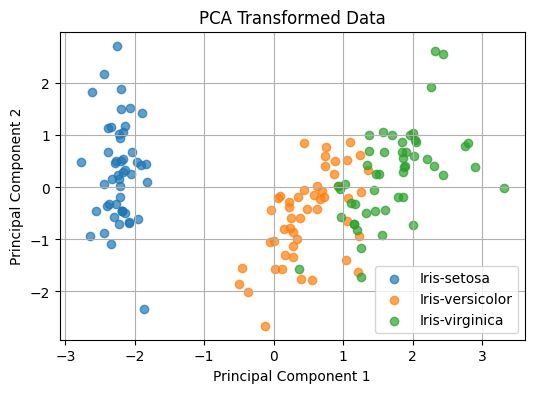

In [13]:
# Plot PCA

plt.figure(figsize=(6,4))

for species in true_labels.unique():
    mask = true_labels == species
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=species, alpha=0.7)

plt.legend()
plt.title("PCA Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

## DBSCAN Clustering

**DBSCAN on Original Data**

Tune eps and min_samples on Original Data

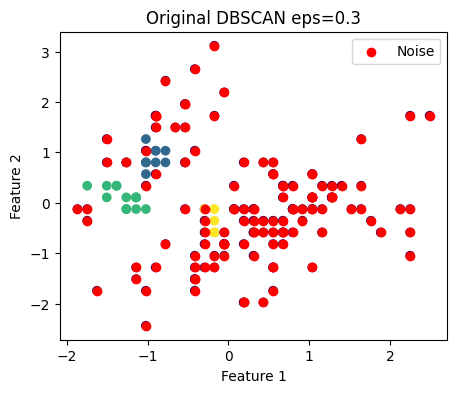

In [14]:

# Trial 1
# DBSCAN eps=0.3
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(5,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1] , c=labels)
plt.scatter(X_scaled[labels == -1, 0], X_scaled[labels == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Original DBSCAN eps=0.3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

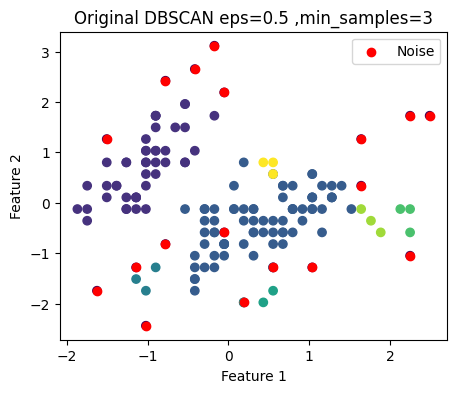

In [29]:
# Trial 2
# DBSCAN eps=0.5
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(5,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(X_scaled[labels == -1, 0], X_scaled[labels == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Original DBSCAN eps=0.5 ,min_samples=3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

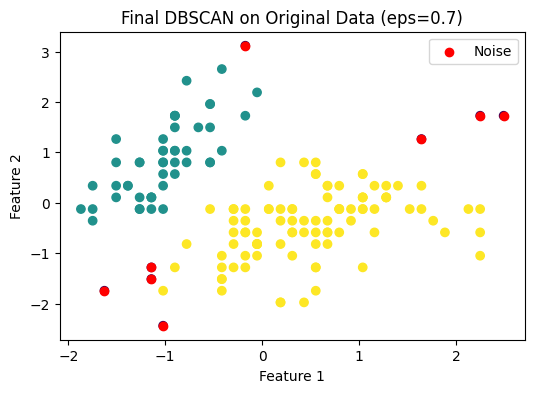

In [27]:

# Final DBSCAN on Original Data
# DBSCAN eps=0.7
dbscan_original = DBSCAN(eps=0.7, min_samples=5)
labels_original = dbscan_original.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_original)
plt.scatter(X_scaled[labels_original == -1, 0], X_scaled[labels_original == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Final DBSCAN on Original Data (eps=0.7)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**DBSCAN on PCA Data**

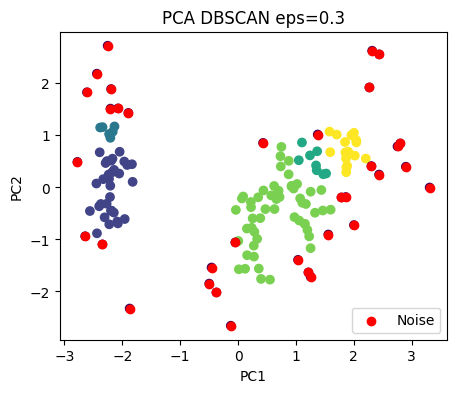

In [17]:
# Tune eps and min_samples on PCA data

# Trial 1
# DBSCAN eps=0.3
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

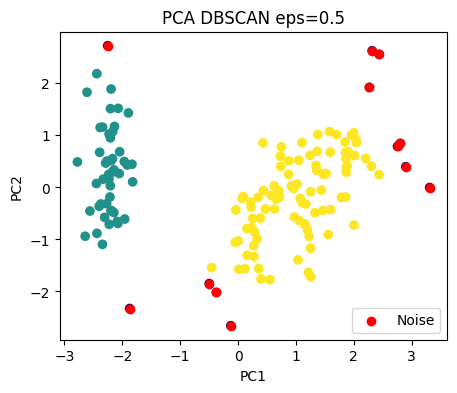

In [18]:
# Trial 2
# DBSCAN eps=0.5
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.scatter(X_pca[labels == -1, 0], X_pca[labels== -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("PCA DBSCAN eps=0.5")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

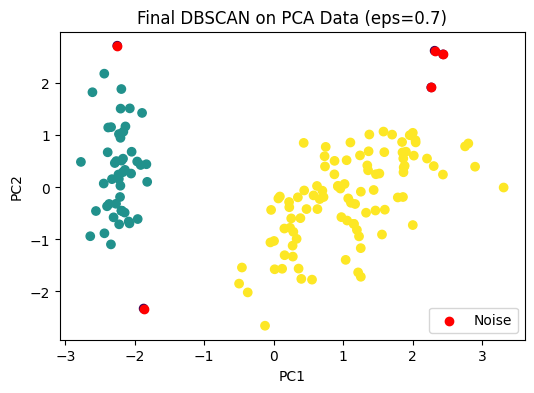

In [19]:
# Final DBSCAN on PCA Data
# DBSCAN eps=0.7
dbscan_pca = DBSCAN(eps=0.7, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.scatter(X_pca[labels_pca == -1, 0], X_pca[labels_pca == -1, 1],
            c='red', label='Noise')
plt.legend()
plt.title("Final DBSCAN on PCA Data (eps=0.7)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Analysis

=== DBSCAN Results Comparison ===
Original Data Labels: {np.int64(0), np.int64(1), np.int64(-1)}
PCA Data Labels:      {np.int64(0), np.int64(1), np.int64(-1)}


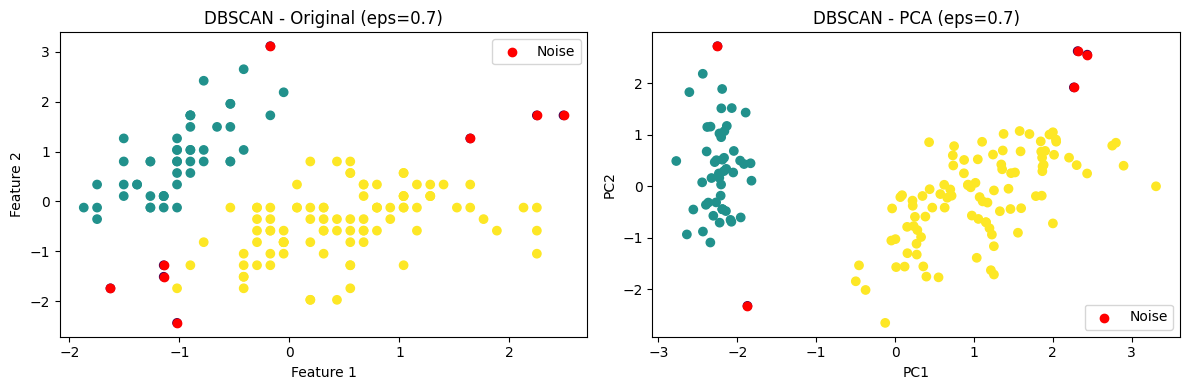

In [21]:
# - Compare results
print("=== DBSCAN Results Comparison ===")
print(f"Original Data Labels: {set(labels_original)}")
print(f"PCA Data Labels:      {set(labels_pca)}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Original
ax1.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_original )
ax1.scatter(X_scaled[labels_original == -1, 0], X_scaled[labels_original == -1, 1]
            ,c='red', label='Noise')
ax1.set_title("DBSCAN - Original (eps=0.7)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()

# PCA
ax2.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
ax2.scatter(X_pca[labels_pca == -1, 0], X_pca[labels_pca == -1, 1],
            c='red', label='Noise')

ax2.set_title("DBSCAN - PCA (eps=0.7)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()

plt.tight_layout()
plt.show()

## **eps=0.7 provided the best balance between cluster formation and noise reduction**

In [22]:
#  Count clusters
n_clusters_orig = len(set(labels_original)) - (1 if -1 in labels_original else 0)
n_clusters_pca  = len(set(labels_pca))      - (1 if -1 in labels_pca else 0)

print(f"Original → Clusters: {n_clusters_orig}")
print(f"PCA      → Clusters: {n_clusters_pca}")


Original → Clusters: 2
PCA      → Clusters: 2


In [23]:
#  Count noise points
n_noise_orig = list(labels_original).count(-1)
n_noise_pca  = list(labels_pca).count(-1)

print(f"Original → Noise points: {n_noise_orig}")
print(f"PCA      → Noise points: {n_noise_pca}")


Original → Noise points: 8
PCA      → Noise points: 5


In [24]:
tuning_results = pd.DataFrame({
    "Data": ["Original", "PCA"],
    "eps": [0.7, 0.7],
    "min_samples": [5, 5],
    "Clusters": [n_clusters_orig, n_clusters_pca],
    "Noise Points": [n_noise_orig, n_noise_pca]
})

tuning_results

,Data,eps,min_samples,Clusters,Noise Points
0,Original,0.7,5,2,8
1,PCA,0.7,5,2,5


In [ ]:
print("PCA reduced noise points from 8 to 5 while keeping the number of clusters the same (2), which indicates improved clustering quality.")


PCA reduced noise points from 8 to 5 while keeping the number of clusters the same (2), which indicates improved clustering quality.
